In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
df=pd.read_csv('data_banknote_authentication_dataset.csv',header=0)

In [55]:
df.head()

,Notes,Variance_WT,Skewness_WT,Curtosis_WT,Entropy,Class
0,1,3.62160,8.6661,-2.8073,-0.44699,0
1,2,4.54590,8.1674,-2.4586,-1.46210,0
2,3,3.86600,-2.6383,1.9242,0.10645,0
3,4,3.45660,9.5228,-4.0112,-3.59440,0
4,5,0.32924,-4.4552,4.5718,-0.98880,0


In [56]:
df.columns

Index(['Notes', 'Variance_WT', 'Skewness_WT', 'Curtosis_WT', 'Entropy',
       'Class'],
      dtype='object')

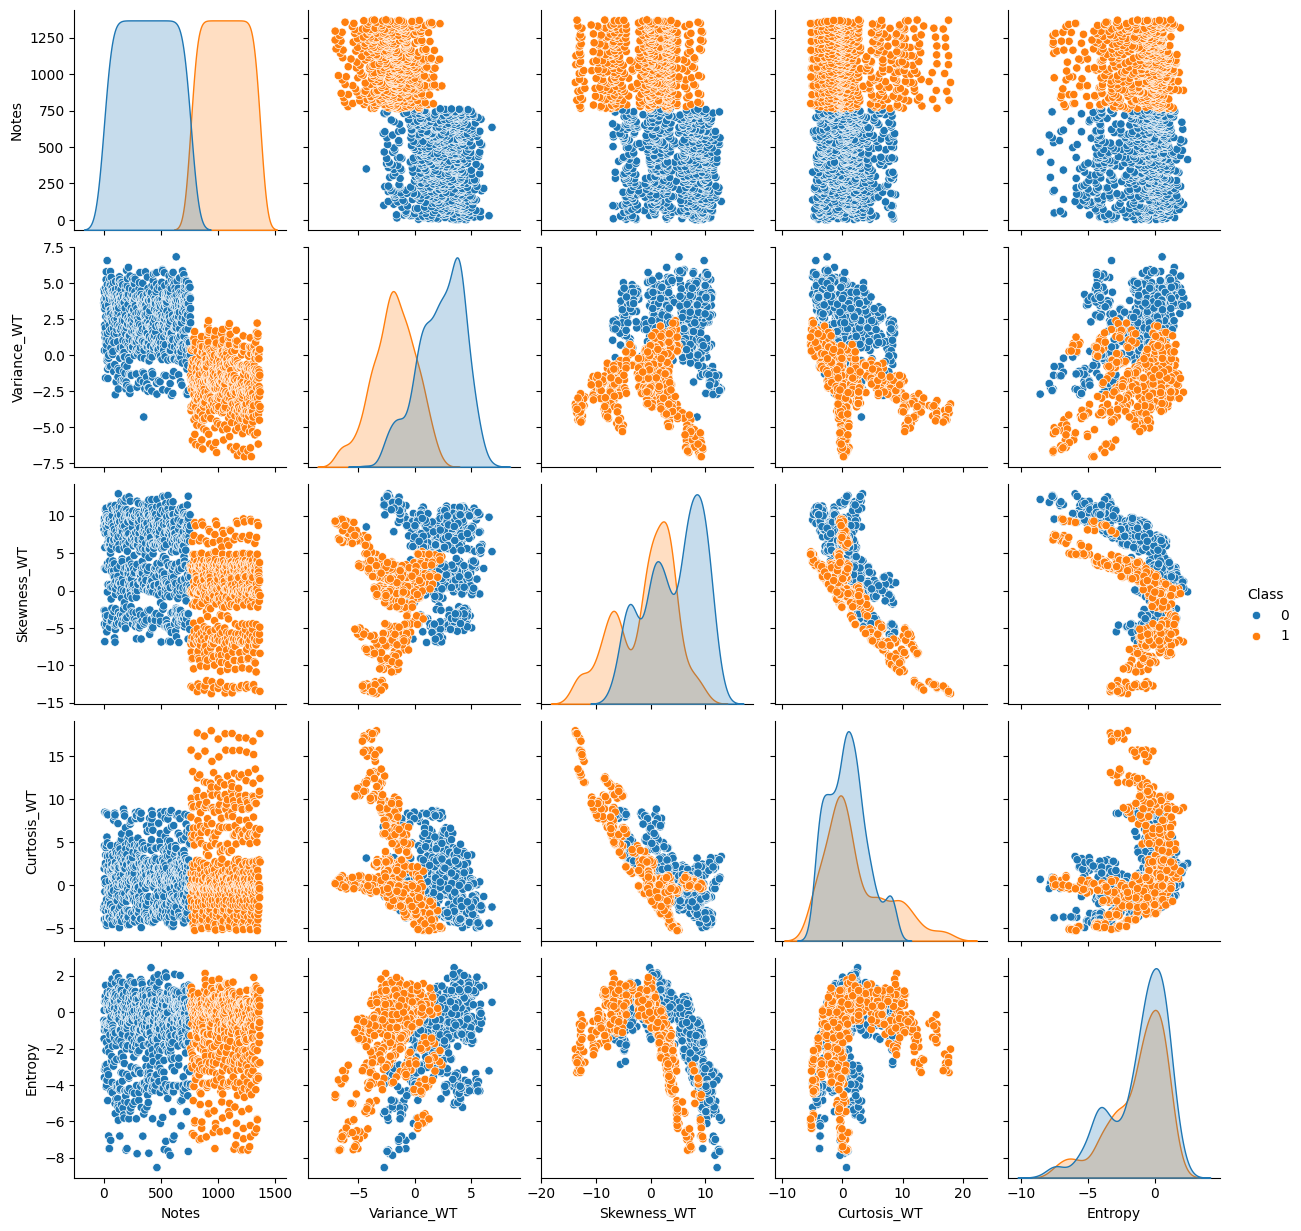

In [57]:
sns.pairplot(df,hue='Class')

In [58]:
X=df.drop("Class",axis=1)

In [59]:
y=df['Class']

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.15,random_state=101)

In [62]:
from sklearn.model_selection import GridSearchCV

In [63]:
from sklearn.ensemble import RandomForestClassifier

In [64]:
n_estimators=[64,100,128,200]

In [65]:
max_features=[2,3,4]

In [66]:
bootstrap=[True,False]

In [67]:
oob_score = [True,False ]

In [68]:
param_grid={'n_estimators':n_estimators,'max_features':max_features,'bootstrap':bootstrap,'oob_score':oob_score}

In [69]:
rf=RandomForestClassifier()

In [70]:
grid=GridSearchCV(rf,param_grid)

In [71]:
grid.fit(X_train,y_train);

C:\Users\Kirat\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
60 fits failed out of a total of 240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Kirat\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Kirat\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\Kirat\AppData\Roaming\Python\Python313\site-

In [72]:
grid.best_params_

{'bootstrap': True, 'max_features': 2, 'n_estimators': 64, 'oob_score': True}

In [73]:
rf=RandomForestClassifier(max_features=2,n_estimators=200,oob_score=True)

In [74]:
rf.fit(X_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,2
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [75]:
rf.oob_score_

1.0

In [76]:
predictions=grid.predict(X_test)

In [77]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay,accuracy_score

In [78]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       124
           1       1.00      1.00      1.00        82

    accuracy                           1.00       206
   macro avg       1.00      1.00      1.00       206
weighted avg       1.00      1.00      1.00       206



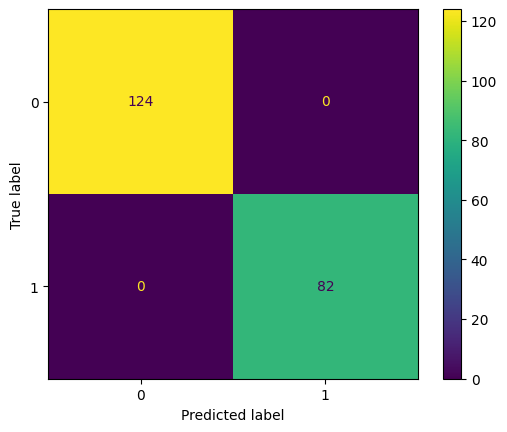

In [79]:
ConfusionMatrixDisplay.from_estimator(rf,X_test,y_test)

In [80]:
errors=[]
misclassification=[]

for n in range(1,200):
    rf=RandomForestClassifier(n_estimators=n,max_features=2)
    rf.fit(X_train,y_train)
    preds=rf.predict(X_test)
    err=1-accuracy_score(y_test,preds)
    n_missed=np.sum(preds!=y_test)


In [81]:
errors.append(err)
misclassifications.append(n_missed)

NameError: name 'misclassifications' is not defined